In [1]:
import numpy as np
from scipy import stats, optimize, linalg
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

## Steepest Descent

Perhaps the most obvious direction to choose when attempting to minimize a function $f$ starting at $x_n$ is the direction of *steepest descent*, or $-f^\prime(x_n)$. This is the direction that is orthogonal to the contours of $f$ at the point $x_n$ and hence is the direction in which $f$ is changing most rapidly at $x_n$.

Direction of steepest descent.

The updating procedure for a steepest descent algorithm, given the current estimate $x_n$, is then

$$
x_{n+1} = x_n - \alpha_n f^\prime(x_n)

$$

While it might seem logical to always go in the direction of steepest descent, it can occasionally lead to some problems. In particular, when certain parameters are highly correlated with each other, the steepest descent algorithm can require many steps to reach the minimum.

The figure below illustrates a function whose contours are highly correlated and hence elliptical.

Steepest descent with highly correlated parameters.

Depending on the starting value, the steepest descent algorithm could take many steps to wind its way towards the minimum.

### Example: Multivariate Normal

One can use steepest descent to compute the maximum likelihood estimate of the mean in a multivariate Normal density, given a sample of data. However, when the data are highly correlated, as they are in the simulated example below, the log-likelihood surface can be come difficult to optimize. In such cases, a very narrow ridge develops in the log-likelihood that can be difficult for the steepest descent algorithm to navigate.

In the example below, we actually compute the *negative* log-likelihood because the algorith is designed to *minimize* functions.


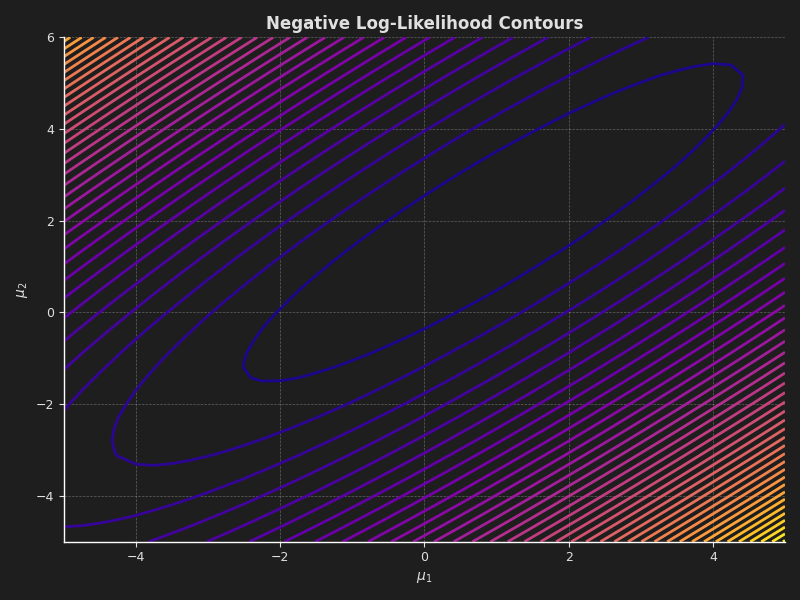

In [2]:
rng = np.random.default_rng(int('20170810'))
mu = [1, 2]
S = np.array([[1, 0.9], [0.9, 1]])
x = rng.multivariate_normal(mu, S, size=500)

def nloglike(mu1, mu2):
    mu_vec = np.array([mu1, mu2])
    from scipy.stats import multivariate_normal
    mv = multivariate_normal(mean=mu_vec, cov=S)
    return -np.sum(mv.logpdf(x))

nx, ny = 40, 40
xg = np.linspace(-5, 5, nx+1)
yg = np.linspace(-5, 6, ny+1)
xx, yy = np.meshgrid(xg, yg)

nLL = np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        nLL[i, j] = nloglike(xx[i, j], yy[i, j])

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(xg, yg, nLL, levels=40)
ax.set_xlabel(r'$\mu_1$')
ax.set_ylabel(r'$\mu_2$')
ax.set_title('Negative Log-Likelihood Contours')
plt.tight_layout()

Note that in the figure above the surface is highly stretched and that the minimum $(1, 2)$ lies in the middle of a narrow valley. For the steepest descent algorithm we will start at the point $(-5, -2)$ and track the path of the algorithm.


We can see that the path of the algorthm is rather winding as it traverses the narrow valley. Now, we have fixed the step-length in this case, which is probably not optimal. However, one can still see that the algorithm has some difficulty navigating the surface because the direction of steepest descent does not take one directly towards the minimum ever.
